In [1]:
import pickle

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

X_stress = load_pickle("X_stress.pkl")
X_strain = load_pickle("X_strain.pkl")
y_stress = load_pickle("y_stress.pkl")
y_strain = load_pickle("y_strain.pkl")

'''5 values:
Q (параметр нагрузки/деформации)
k ( коэффициент калибровочного участка)
alpha (угол, геометрия)
mu (коэффициент трения)
v (скорость)
'''
print("X_stress:", type(X_stress), getattr(X_stress, "shape", None))
print("X_strain:", type(X_strain), getattr(X_strain, "shape", None))
print("y_stress:", type(y_stress), getattr(y_stress, "shape", None))
print("y_strain:", type(y_strain), getattr(y_strain, "shape", None))

print("\nExample values:")
print("X_stress[0]:", X_stress[0])
print("y_stress[0]:", y_stress[0])


X_stress: <class 'numpy.ndarray'> (4, 2028, 5)
X_strain: <class 'numpy.ndarray'> (4, 2438, 5)
y_stress: <class 'numpy.ndarray'> (4, 2028, 20)
y_strain: <class 'numpy.ndarray'> (4, 2438, 20)

Example values:
X_stress[0]: [[ 0.1    0.     8.     0.1   10.   ]
 [ 0.1    0.     8.     0.025 10.   ]
 [ 0.1    0.     8.     0.05  10.   ]
 ...
 [ 0.15   0.    20.     0.1    5.   ]
 [ 0.15   0.    20.     0.025  5.   ]
 [ 0.15   0.    20.     0.05   5.   ]]
y_stress[0]: [[-132.998   -129.095   -118.699   ...  118.626    134.583    140.446  ]
 [-132.998   -129.095   -118.699   ...  118.626    134.583    140.446  ]
 [-132.998   -129.095   -118.699   ...  118.626    134.583    140.446  ]
 ...
 [-121.443   -116.65    -106.736   ...   86.1895    94.37975   97.38555]
 [-121.443   -116.65    -106.736   ...   86.1895    94.37975   97.38555]
 [-121.443   -116.65    -106.736   ...   86.1895    94.37975   97.38555]]


In [2]:
# Распаковка Raw_data.7z и парсинг .txt -> pkl тестовой выборки (деформации)
import os, re, sys, subprocess, pickle
from glob import glob
from pathlib import Path
import numpy as np

try:
    import py7zr
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "py7zr"])
    import py7zr

ARCHIVE_PATH = "/content/Raw_data.7z"
RAW_DIR      = Path("/content/raw_data")
PKL_DIR      = Path("/content")
TAG          = "test"

for name in ("X_strain", "y_strain"):
    p = PKL_DIR / f"{name}_components_{TAG}.pkl"
    if p.exists():
        p.unlink()

RAW_DIR.mkdir(parents=True, exist_ok=True)
if list(RAW_DIR.glob("*.txt")):
    print(f"Папка {RAW_DIR} уже содержит .txt — распаковка пропущена.")
else:
    if not Path(ARCHIVE_PATH).exists():
        raise FileNotFoundError(f"Не найден архив {ARCHIVE_PATH}. Загрузите Raw_data.7z в /content/.")
    with py7zr.SevenZipFile(ARCHIVE_PATH, mode="r") as z:
        z.extractall(path=str(RAW_DIR))
    print(f"Извлечено {len(list(RAW_DIR.glob('*.txt')))} файлов")

N_R               = 20
STEADY_STATE_BAND = (0.25, 0.75)

COL_COOR1, COL_COOR2 = 1, 2
COL_PE_PE11, COL_PE_PE22, COL_PE_PE33, COL_PE_PE12 = 13, 14, 15, 16

_PARAM_RE = re.compile(
    r"1020_2a_(?P<a>\d+)_rd_(?P<rd>\d+)_cal_(?P<cal>\d+)_v_(?P<v>\d+)_f_(?P<f>\d+)")
_WIRE_SECTION_RE = re.compile(
    r"Field Output reported at nodes for part:\s*WIRE_1-1.*?"
    r"(?=Field Output reported|\Z)", flags=re.S)
_DATA_ROW_RE = re.compile(r"^\s+(\d+)\s+(.*)$", flags=re.M)


def parse_filename_params(fname):
    # имя файла -> [Q, k, α, μ, v] в шкале обучающего pkl
    m = _PARAM_RE.search(os.path.basename(fname))
    if not m:
        return None
    a, rd, cal = float(m.group("a")), float(m.group("rd")), float(m.group("cal"))
    v, f = float(m.group("v")), float(m.group("f"))
    return np.array([rd / 10000.0, cal / 100.0, a / 20.0, f / 1000.0, v / 100.0],
                    dtype=np.float32)


def parse_rpt_file(path):
    with open(path, errors="ignore") as fh:
        text = fh.read()
    m = _WIRE_SECTION_RE.search(text)
    if not m:
        return np.zeros((0, 27), dtype=np.float64)
    rows = []
    for mm in _DATA_ROW_RE.finditer(m.group(0)):
        toks = mm.group(2).split()
        if len(toks) < 26:
            continue
        try:
            vals = [float(t) for t in toks[:26]]
        except ValueError:
            continue
        rows.append([float(mm.group(1))] + vals)
    if not rows:
        return np.zeros((0, 27), dtype=np.float64)
    return np.asarray(rows, dtype=np.float64)


def radial_profile(arr, col_indices, n_r=N_R, z_band=STEADY_STATE_BAND):
    z = arr[:, COL_COOR2]
    z_lo = z.min() + z_band[0] * (z.max() - z.min())
    z_hi = z.min() + z_band[1] * (z.max() - z.min())
    band = arr[(z >= z_lo) & (z <= z_hi)]
    if band.shape[0] == 0:
        return np.full((4, n_r), np.nan)
    r = band[:, COL_COOR1]
    edges   = np.linspace(0.0, max(r.max(), 1e-12) * 1.0001, n_r + 1)
    centres = 0.5 * (edges[:-1] + edges[1:])
    out = np.full((4, n_r), np.nan)
    populated = np.zeros(n_r, dtype=bool)
    for k in range(n_r):
        sel = (r >= edges[k]) & (r < edges[k + 1])
        if not sel.any():
            continue
        populated[k] = True
        for c, ci in enumerate(col_indices):
            out[c, k] = band[sel, ci].mean()
    if not populated.all():
        good, bad = np.where(populated)[0], np.where(~populated)[0]
        for c in range(4):
            out[c, bad] = np.interp(centres[bad], centres[good], out[c, good])
    return out


def strain_profile(arr, n_r=N_R):
    # планы хранятся в порядке доступа PLANE_ORDER=[2,0,1,3]:
    #   0->ε_θθ(PE33)  1->ε_zz(PE22)  2->ε_rr(PE11)  3->γ_rz(PE12)
    cols = (COL_PE_PE33, COL_PE_PE22, COL_PE_PE11, COL_PE_PE12)
    prof = radial_profile(arr, cols, n_r=n_r)
    prof[3] *= 0.5  # γ_rz (инженерная) -> ε_rz (тензорная): ε_rz = γ_rz / 2
    return prof


files = sorted(glob(str(RAW_DIR / "*.txt")))
if not files:
    raise FileNotFoundError(f"Нет .txt файлов в {RAW_DIR}")
print(f"Найдено {len(files)} .txt файлов")

params_rows, strain_profs, skipped = [], [], []
for fn in files:
    params = parse_filename_params(fn)
    if params is None:
        skipped.append(fn); continue
    arr = parse_rpt_file(fn)
    if arr.shape[0] == 0:
        skipped.append(fn); continue
    e_prof = strain_profile(arr)
    if not np.isfinite(e_prof).all():
        skipped.append(fn); continue
    params_rows.append(params)
    strain_profs.append(e_prof)

if not strain_profs:
    raise RuntimeError("Все файлы пропущены при парсинге.")

N = len(strain_profs)
strain_arr = np.stack(strain_profs, axis=1).astype(np.float32)   # (4, N, 20)
params_arr = np.stack(params_rows, axis=0).astype(np.float32)    # (N, 5)
X_block    = np.broadcast_to(params_arr[None, :, :], (4, N, 5)).copy()

paths = {
    "X_strain": PKL_DIR / f"X_strain_components_{TAG}.pkl",
    "y_strain": PKL_DIR / f"y_strain_components_{TAG}.pkl",
}
with open(paths["X_strain"], "wb") as fh: pickle.dump(X_block,    fh)
with open(paths["y_strain"], "wb") as fh: pickle.dump(strain_arr, fh)

print(f"\nСохранено {N}/{len(files)} наборов (пропущено {len(skipped)})")
labels = ["plane 0 -> ε_θθ (PE33)", "plane 1 -> ε_zz (PE22)",
          "plane 2 -> ε_rr (PE11)", "plane 3 -> ε_rz (PE12, /2)"]
for c, lbl in enumerate(labels):
    v = strain_arr[c].ravel()
    print(f"  {lbl:28s}: [{v.min():+.5f}, {v.max():+.5f}]   mean_abs={np.abs(v).mean():.5f}")
for k, p in paths.items():
    sh = X_block.shape if k.startswith("X") else strain_arr.shape
    print(f"  {k:9s} -> {p}   shape {sh}")

Извлечено 74 файлов
Найдено 74 .txt файлов

Сохранено 74/74 наборов (пропущено 0)
  plane 0 -> ε_θθ (PE33)      : [-0.18419, -0.07446]   mean_abs=0.09988
  plane 1 -> ε_zz (PE22)      : [+0.14719, +0.37399]   mean_abs=0.19879
  plane 2 -> ε_rr (PE11)      : [-0.18987, -0.07244]   mean_abs=0.09891
  plane 3 -> ε_rz (PE12, /2)  : [-0.00151, +0.10835]   mean_abs=0.01842
  X_strain  -> /content/X_strain_components_test.pkl   shape (4, 74, 5)
  y_strain  -> /content/y_strain_components_test.pkl   shape (4, 74, 20)


Тестовый pkl: X (4, 74, 5), y (4, 74, 20), mean|y|=0.10400

=== Обучающая выборка (X_strain.pkl / y_strain.pkl) ===
 X : (48760, 6)   [p1..p5, r]
 y : (48760, 4)   [ε_rr, ε_θθ, ε_zz, ε_rz]
 Mapping: LE33→ε_rr | LE11→ε_θθ | LE22→ε_zz | LE12→ε_rz

Диапазоны y:
  eps_rr    : [ -0.000187,  +3.445060]  mean_abs=0.257347
  eps_tt    : [ -1.727210,  +0.000042]  mean_abs=0.129569
  eps_zz    : [ -1.664075,  +0.000037]  mean_abs=0.127123
  eps_rz    : [ -0.062091,  +0.511980]  mean_abs=0.024035
N_sets (train+test) = 2438

TEST_PLANE_ORDER = [1, 0, 2, 3]
  out 0 (eps_rr): train [pos] 0.2573  test plane 1 [pos] 0.1988  ratio=0.77× ✓
  out 1 (eps_tt): train [neg] 0.1296  test plane 0 [neg] 0.0999  ratio=0.77× ✓
  out 2 (eps_zz): train [neg] 0.1271  test plane 2 [neg] 0.0989  ratio=0.78× ✓
  out 3 (eps_rz): train [mix] 0.0240  test plane 3 [mix] 0.0184  ratio=0.77× ✓

MLP-baseline: [64, 64, 64] (tanh), Adam(lr=0.001), 200 эпох, batch=256  device=CPU

=== 5-fold CV ===
Using device: cpu
Architecture

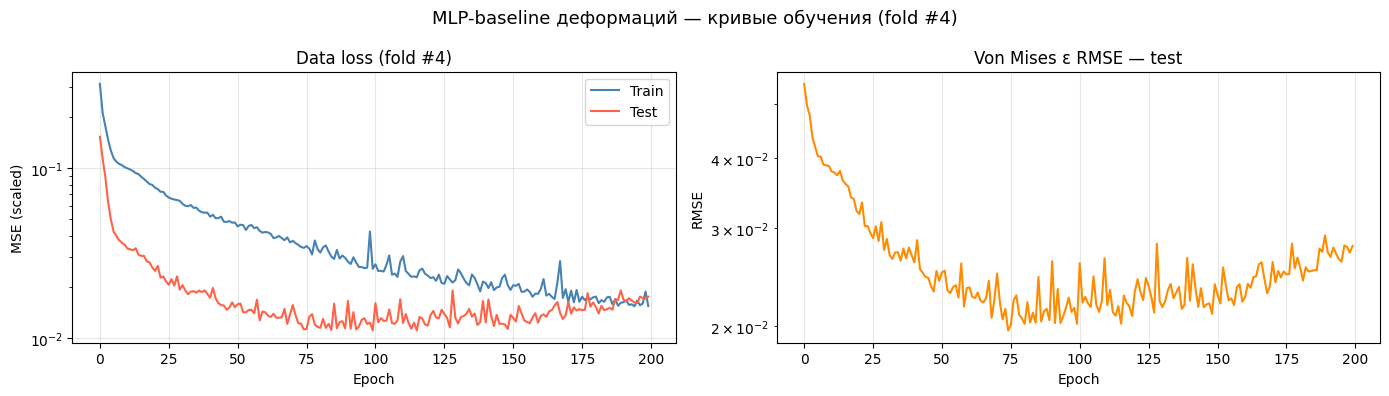

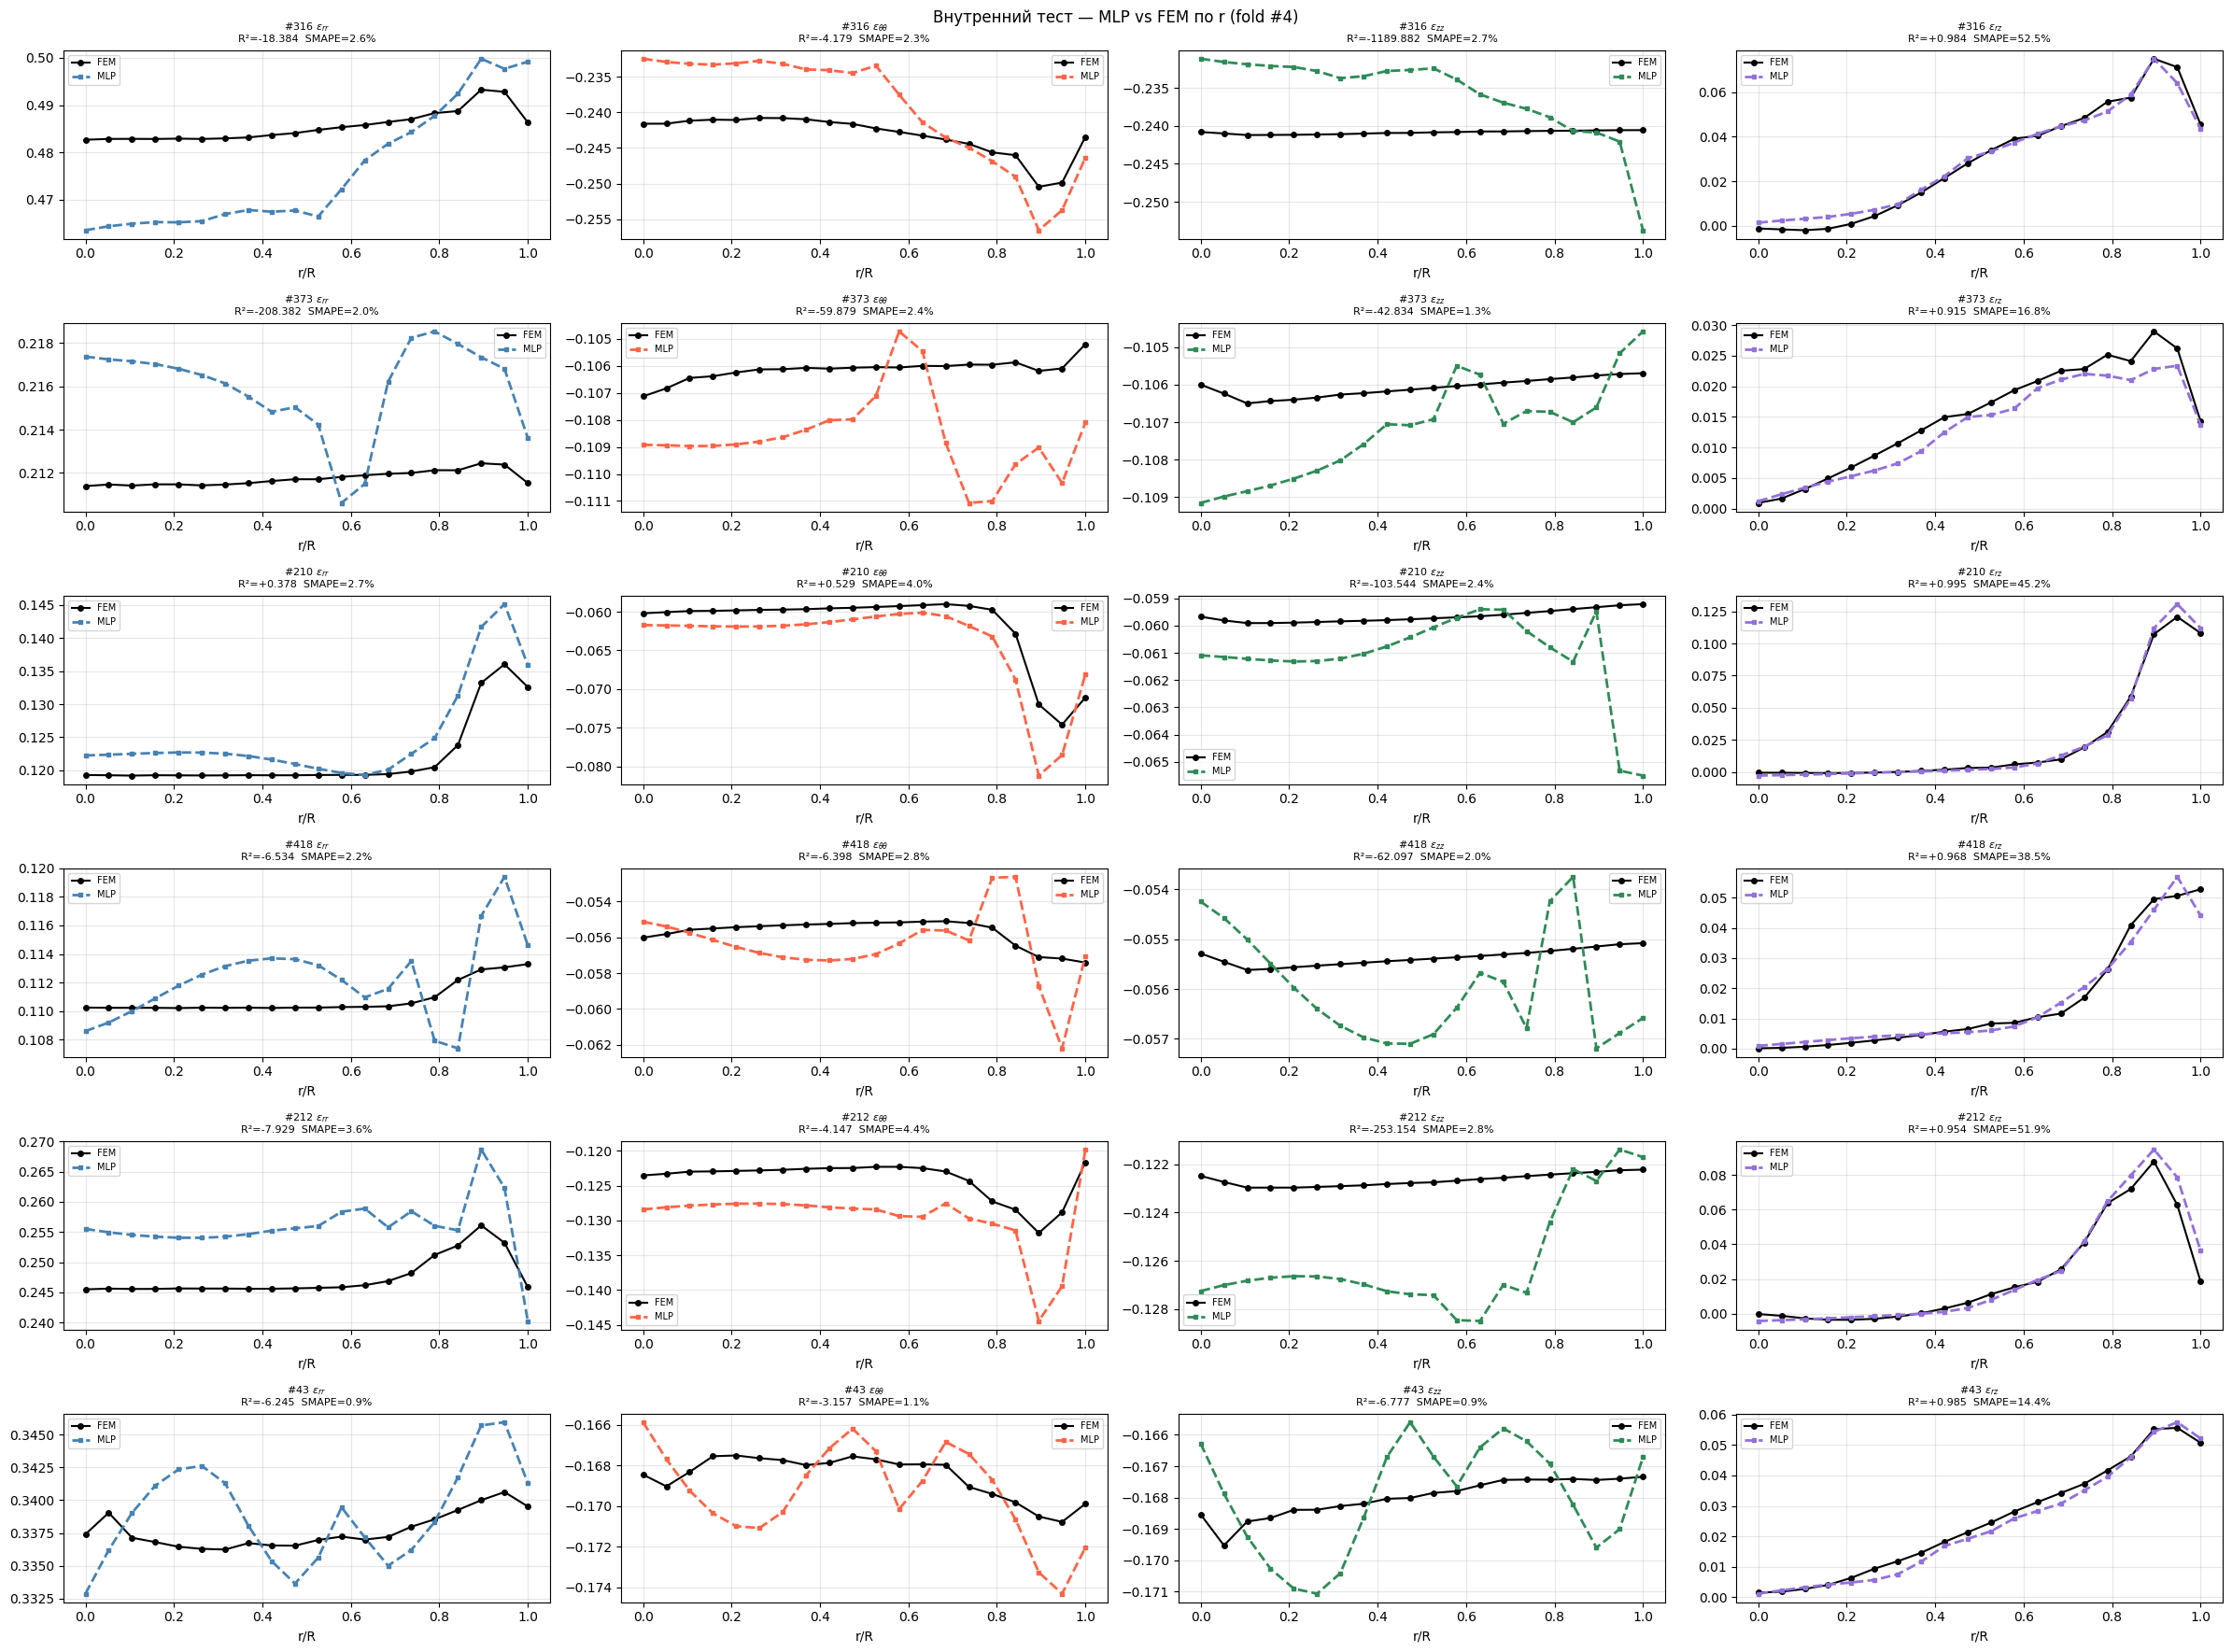

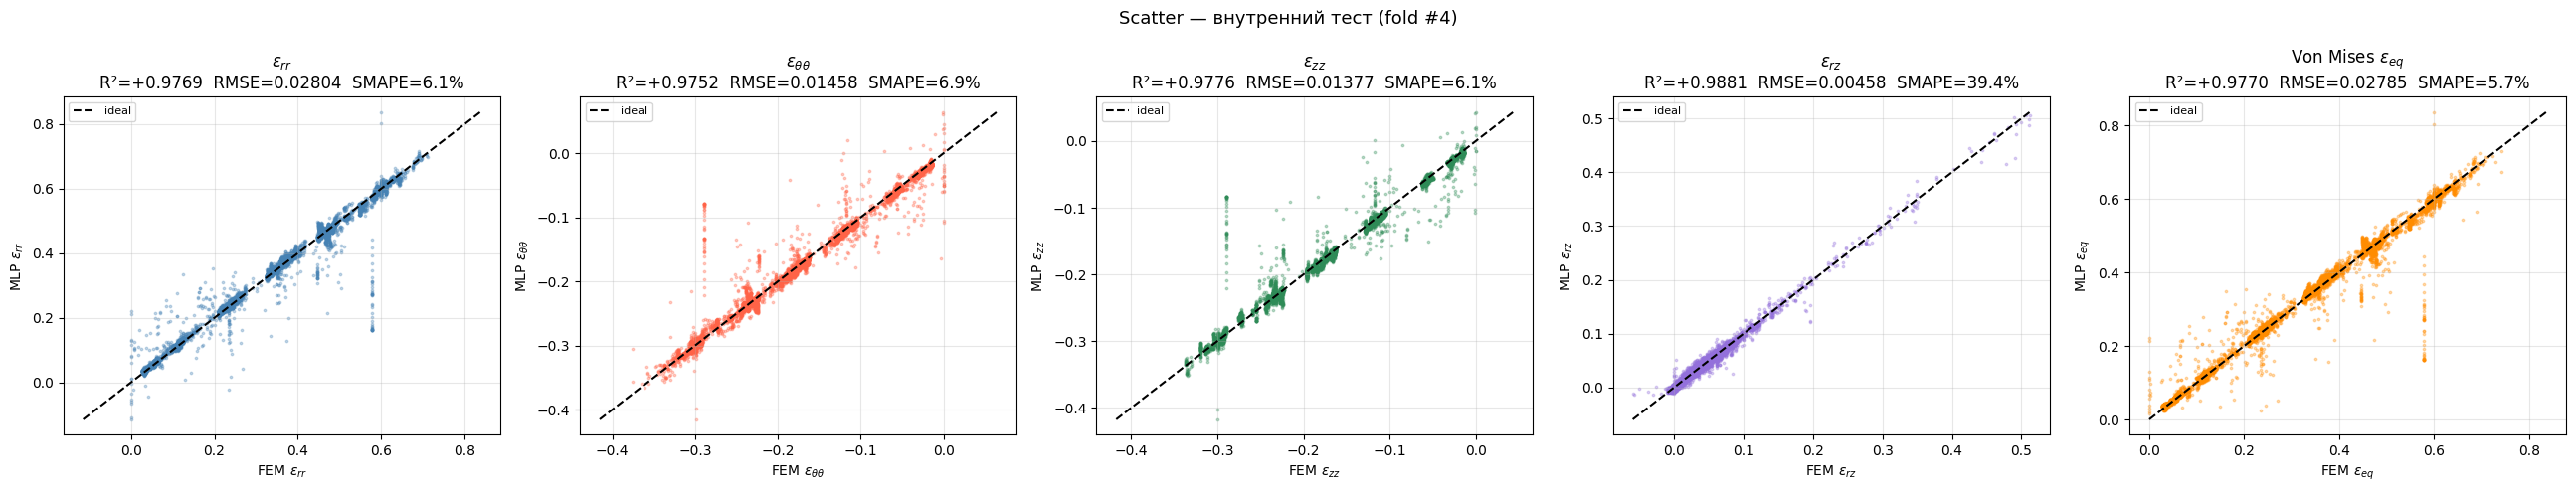


=== Прогон на тестовом pkl ===

── Тест metrics ─────────────────────────
  R²                      : 0.997549
  RMSE (4 comp macro)     : 0.006001
  Von Mises R²            : 0.982920
  SMAPE [%]               : 14.485492
  MAE                     : 0.004823
  Max Error               : 0.033410
  Median AE               : 0.003673
  MSE                     : 0.000042

── Тест per-component ──────────────────
  eps_rr    :  R²=+0.9820   RMSE=0.010124   SMAPE=4.36%
  eps_tt    :  R²=+0.9800   RMSE=0.005336   SMAPE=4.54%
  eps_zz    :  R²=+0.9846   RMSE=0.004680   SMAPE=4.13%
  eps_rz    :  R²=+0.9638   RMSE=0.003864   SMAPE=44.91%


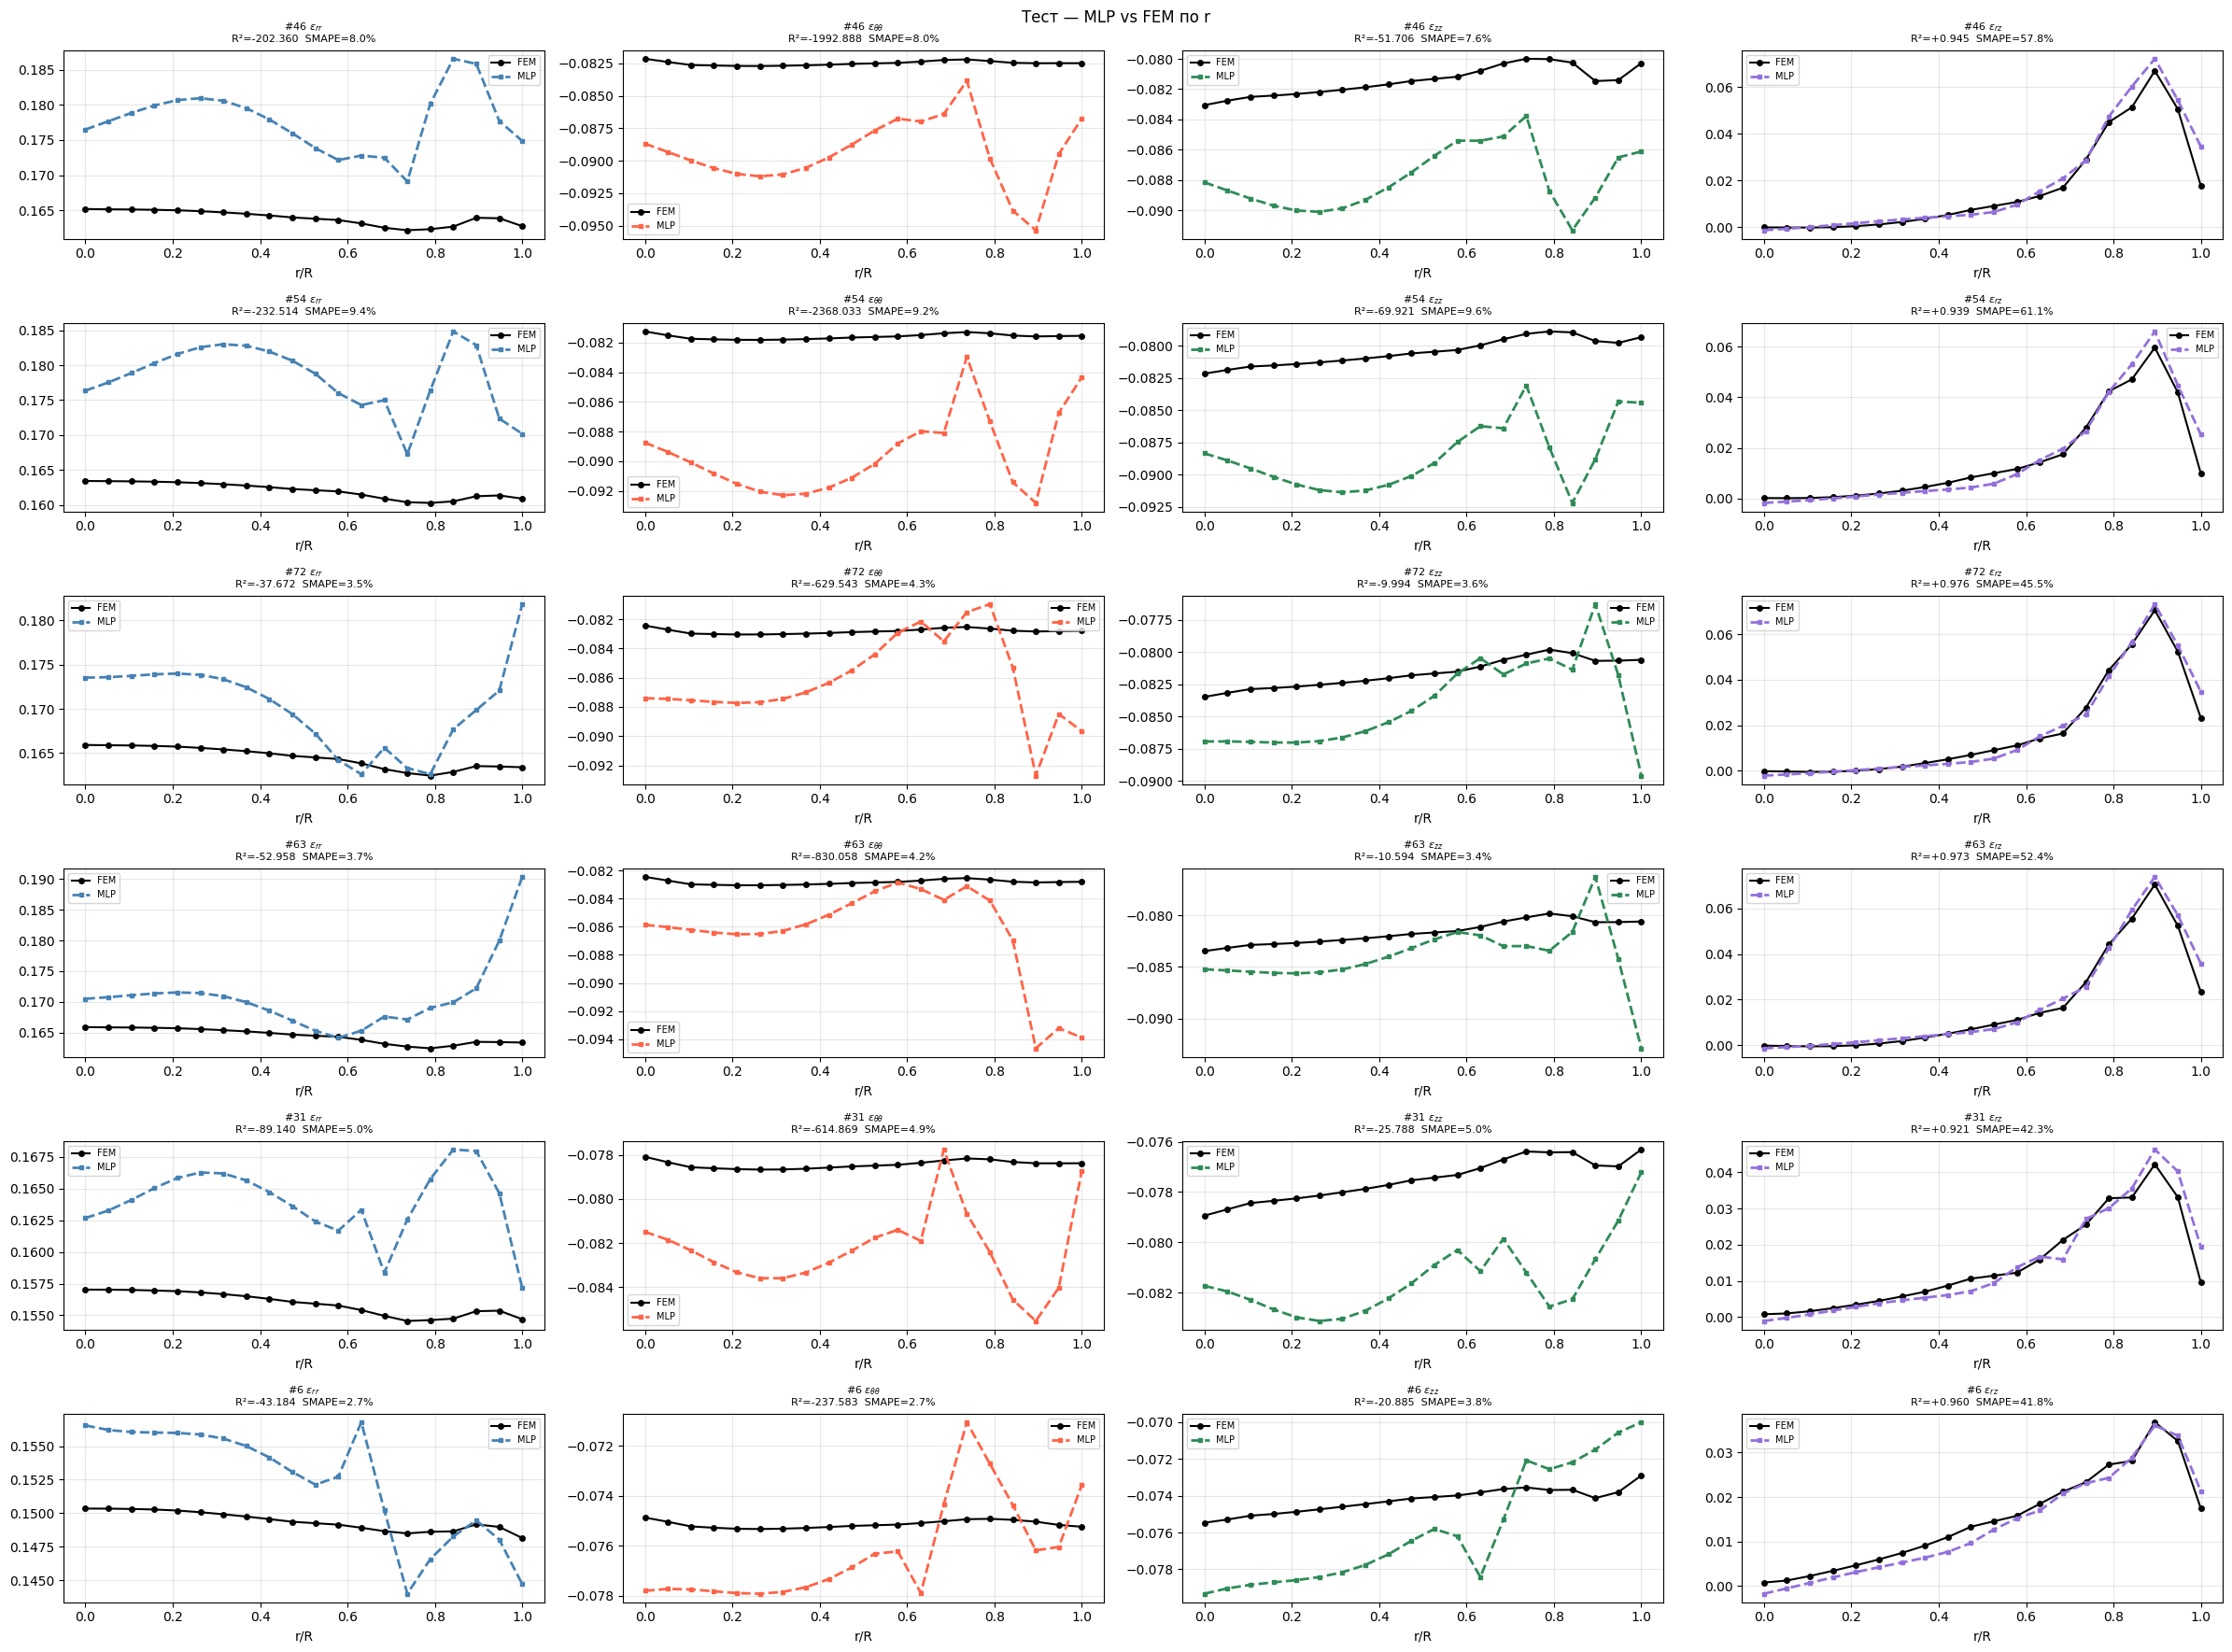

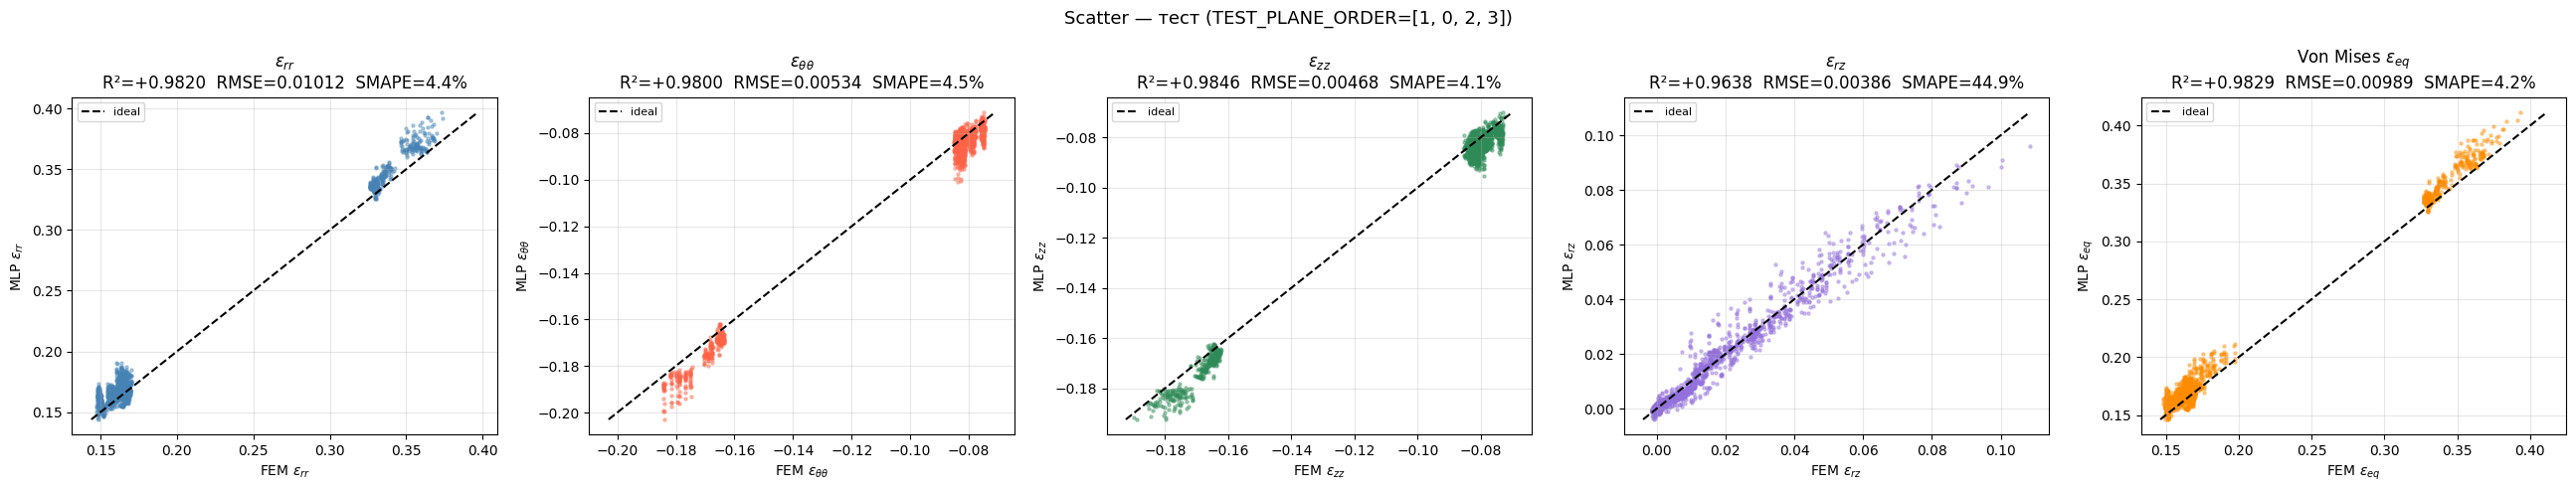


=== Сводная таблица ===
                     K-Fold mean  K-Fold std   Best Fold       Test
R²                      0.960456   0.0279503    0.991722   0.997549
RMSE (4 comp macro)    0.0318131   0.0130935   0.0152437 0.00600108
Von Mises R²             0.89404   0.0732368    0.977049    0.98292
SMAPE [%]                 14.528    0.890569     14.5981    14.4855
MAE                   0.00677954  0.00103506  0.00563292 0.00482305
Max Error                 1.8727     1.08299     0.41683  0.0334099
Median AE             0.00245736 0.000427085  0.00265299 0.00367297
MSE                   0.00163454  0.00123052 0.000302408 4.1952e-05

Время: 5-fold 697.3 с (per-fold 138.0 ± 5.0 с)

Модель сохранена -> /content/artifacts/mlp_strains_baseline.pkl  (39.2 KB)
Архитектура: [64, 64, 64] (tanh)  Adam(lr=0.001)  200 эпох, batch=256


In [4]:
# Запуск MLP-baseline на деформациях (data-only, без физики): 5-fold CV -> тест
import importlib, pickle, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import r2_score, mean_squared_error

import mlp_strains
importlib.reload(mlp_strains)
from mlp_strains import (
    build_strain_dataset, kfold_test_best_model_mlp,
    evaluate_on_external_set, von_mises_strain, smape,
    METRIC_NAMES, STRAIN_COMPONENTS, N_R,
    HIDDEN_LAYERS, ACTIVATION, LEARNING_RATE, EPOCHS, BATCH_SIZE,
)

# план тестового pkl -> позиция выхода модели; [1,0,2,3] выравнивает все 4 компоненты
# с обучающей конвенцией (см. авто-проверку ниже: знаки совпадают, ratio≈0.77 по всем)
TEST_PLANE_ORDER = [1, 0, 2, 3]
TEST_X_PKL = "/content/X_strain_components_test.pkl"
TEST_Y_PKL = "/content/y_strain_components_test.pkl"

for p in (TEST_X_PKL, TEST_Y_PKL):
    if not os.path.exists(p):
        raise FileNotFoundError(f"Не найден {p}. Сначала выполните ячейку парсинга (Cell 1).")
with open(TEST_X_PKL, "rb") as f: X_strain_test = pickle.load(f)
with open(TEST_Y_PKL, "rb") as f: y_strain_test = pickle.load(f)
assert y_strain_test.shape[0] == 4 and y_strain_test.shape[2] == N_R
assert X_strain_test.ndim == 3 and X_strain_test.shape[2] == 5
print(f"Тестовый pkl: X {X_strain_test.shape}, y {y_strain_test.shape}, "
      f"mean|y|={np.abs(y_strain_test).mean():.5f}")

# ── Данные ───────────────────────────────────────────────────────────────────
print("\n=== Обучающая выборка (X_strain.pkl / y_strain.pkl) ===")
X_mlp, y_mlp, r_grid, proc = build_strain_dataset(X_strain, y_strain, n_r=N_R)
print(f"N_sets (train+test) = {proc.shape[0]}")

# проверка согласованности тестового маппинга по знаку и магнитуде
train_means = [float(np.abs(y_mlp[:, i]).mean()) for i in range(4)]
train_signs = []
for i in range(4):
    pos = float((y_mlp[:, i] > 0).mean())
    train_signs.append("pos" if pos > 0.95 else ("neg" if pos < 0.05 else "mix"))
print(f"\nTEST_PLANE_ORDER = {TEST_PLANE_ORDER}")
for i in range(4):
    src = TEST_PLANE_ORDER[i]
    arr = y_strain_test[src]
    vm = float(np.abs(arr).mean())
    pos = float((arr > 0).mean())
    vs = "pos" if pos > 0.95 else ("neg" if pos < 0.05 else "mix")
    ratio = vm / max(train_means[i], 1e-12)
    ok = (0.3 < ratio < 3.0) and (train_signs[i] == "mix" or vs == "mix" or train_signs[i] == vs)
    print(f"  out {i} ({STRAIN_COMPONENTS[i]:6s}): train [{train_signs[i]}] {train_means[i]:.4f}  "
          f"test plane {src} [{vs}] {vm:.4f}  ratio={ratio:.2f}× {'✓' if ok else '⚠'}")

# ── Конфигурация baseline (фиксирована, без Optuna и без физики) ──────────────
N_FOLDS = 5
print(f"\nMLP-baseline: {HIDDEN_LAYERS} ({ACTIVATION}), Adam(lr={LEARNING_RATE}), "
      f"{EPOCHS} эпох, batch={BATCH_SIZE}  device={'GPU' if torch.cuda.is_available() else 'CPU'}")

# ── 5-fold CV ────────────────────────────────────────────────────────────────
print("\n=== 5-fold CV ===")
t_total = time.perf_counter()
kf = kfold_test_best_model_mlp(
    X_mlp, y_mlp,
    n_folds=N_FOLDS, random_state=42,
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
    layer_widths=HIDDEN_LAYERS, activation=ACTIVATION, verbose=True,
)
total_wall = time.perf_counter() - t_total

best_model    = kf["best_model"]
best_mean_X   = kf["best_mean_X"]
best_std_X    = kf["best_std_X"]
best_scaler_y = kf["best_scaler_y"]
best_history  = kf["best_history"]
best_fold_k   = kf["best_fold"]
best_time     = kf["best_elapsed_sec"]
pf, pt = kf["per_fold_metrics"], kf["per_fold_times"]

df = pd.DataFrame(pf, columns=METRIC_NAMES, index=[f"Fold {i+1}" for i in range(N_FOLDS)])
df["time [s]"] = pt
df.loc["mean"] = list(pf.mean(axis=0)) + [pt.mean()]
df.loc["std"]  = list(pf.std(axis=0))  + [pt.std()]
with pd.option_context("display.width", 200, "display.float_format", "{:,.6g}".format):
    print(df[["R²", "RMSE (4 comp macro)", "Von Mises R²", "SMAPE [%]", "MAE", "time [s]"]])
print(f"\nЛучший fold: #{best_fold_k+1}  R²={pf[best_fold_k,0]:+.4f}  "
      f"RMSE={pf[best_fold_k,1]:.6f}  VM R²={pf[best_fold_k,2]:+.4f}  время={best_time:.1f} с")

comp_names = [r"$\varepsilon_{rr}$", r"$\varepsilon_{\theta\theta}$",
              r"$\varepsilon_{zz}$", r"$\varepsilon_{rz}$"]
colors = ["steelblue", "tomato", "seagreen", "mediumpurple"]

# ── Кривые обучения (лучший fold) ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(best_history["train_losses"], label="Train", color="steelblue")
axes[0].plot(best_history["test_losses"],  label="Test",  color="tomato")
axes[0].set(xlabel="Epoch", ylabel="MSE (scaled)", yscale="log",
            title=f"Data loss (fold #{best_fold_k+1})")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(best_history["vm_rmse_test"], color="darkorange")
axes[1].set(xlabel="Epoch", ylabel="RMSE", yscale="log", title="Von Mises ε RMSE — test")
axes[1].grid(True, alpha=0.3)
plt.suptitle(f"MLP-baseline деформаций — кривые обучения (fold #{best_fold_k+1})", fontsize=13)
plt.tight_layout(); plt.show()

# ── Внутренний тест (лучший fold) — профили + scatter ────────────────────────
y_true_in, y_pred_in = kf["fold_test_arrays"][best_fold_k]
n_sets_in = len(y_true_in) // N_R
N_SHOW = min(6, n_sets_in)
show_idx = np.random.default_rng(42).choice(n_sets_in, size=N_SHOW, replace=False)
fig, axes = plt.subplots(N_SHOW, 4, figsize=(24, N_SHOW * 3))
for row, pi in enumerate(show_idx):
    for col in range(4):
        ax = axes[row, col] if N_SHOW > 1 else axes[col]
        fem = y_true_in[pi*N_R:(pi+1)*N_R, col]
        mlp = y_pred_in[pi*N_R:(pi+1)*N_R, col]
        ax.plot(r_grid, fem, "o-",  color="black",       ms=4, lw=1.5, label="FEM")
        ax.plot(r_grid, mlp, "s--", color=colors[col],   ms=3, lw=2,   label="MLP")
        ax.set_title(f"#{pi} {comp_names[col]}\nR²={r2_score(fem, mlp):+.3f}  "
                     f"SMAPE={smape(fem, mlp):.1f}%", fontsize=8)
        ax.set_xlabel("r/R"); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.suptitle(f"Внутренний тест — MLP vs FEM по r (fold #{best_fold_k+1})", fontsize=12)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for col, (cn, cl) in enumerate(zip(comp_names, colors)):
    yt, yp = y_true_in[:, col], y_pred_in[:, col]
    axes[col].scatter(yt, yp, s=3, alpha=0.3, color=cl)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    axes[col].plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
    axes[col].set(xlabel=f"FEM {cn}", ylabel=f"MLP {cn}",
                  title=f"{cn}\nR²={r2_score(yt, yp):+.4f}  "
                        f"RMSE={np.sqrt(mean_squared_error(yt, yp)):.5f}  SMAPE={smape(yt, yp):.1f}%")
    axes[col].legend(fontsize=8); axes[col].grid(True, alpha=0.3)
vmt, vmp = von_mises_strain(y_true_in), von_mises_strain(y_pred_in)
axes[4].scatter(vmt, vmp, s=3, alpha=0.3, color="darkorange")
lo, hi = min(vmt.min(), vmp.min()), max(vmt.max(), vmp.max())
axes[4].plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
axes[4].set(xlabel=r"FEM $\varepsilon_{eq}$", ylabel=r"MLP $\varepsilon_{eq}$",
            title=fr"Von Mises $\varepsilon_{{eq}}$" + f"\nR²={r2_score(vmt, vmp):+.4f}  "
                  f"RMSE={np.sqrt(mean_squared_error(vmt, vmp)):.5f}  SMAPE={smape(vmt, vmp):.1f}%")
axes[4].legend(fontsize=8); axes[4].grid(True, alpha=0.3)
plt.suptitle(f"Scatter — внутренний тест (fold #{best_fold_k+1})", fontsize=13)
plt.tight_layout(); plt.show()

# ── Тестовая выборка ─────────────────────────────────────────────────────────
print("\n=== Прогон на тестовом pkl ===")
ext = evaluate_on_external_set(
    best_model, best_mean_X, best_std_X, best_scaler_y,
    X_strain_test, y_strain_test, n_r=N_R,
    label="Тест", plane_order=TEST_PLANE_ORDER, verbose=True,
)
y_true_ext, y_pred_ext = ext["y_true"], ext["y_pred"]
r_grid_ext = ext["r_grid"]
n_sets_ext = ext["proc"].shape[0]

N_SHOW_E = min(6, n_sets_ext)
show_idx_e = np.random.default_rng(42).choice(n_sets_ext, size=N_SHOW_E, replace=False)
fig, axes = plt.subplots(N_SHOW_E, 4, figsize=(24, N_SHOW_E * 3))
for row, pi in enumerate(show_idx_e):
    for col in range(4):
        ax = axes[row, col] if N_SHOW_E > 1 else axes[col]
        fem = ext["per_set"]["true"][pi, :, col]
        mlp = ext["per_set"]["mlp"][pi, :, col]
        ax.plot(r_grid_ext, fem, "o-",  color="black",     ms=4, lw=1.5, label="FEM")
        ax.plot(r_grid_ext, mlp, "s--", color=colors[col], ms=3, lw=2,   label="MLP")
        ax.set_title(f"#{pi} {comp_names[col]}\nR²={r2_score(fem, mlp):+.3f}  "
                     f"SMAPE={smape(fem, mlp):.1f}%", fontsize=8)
        ax.set_xlabel("r/R"); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.suptitle("Тест — MLP vs FEM по r", fontsize=12)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for col, (cn, cl) in enumerate(zip(comp_names, colors)):
    yt, yp = y_true_ext[:, col], y_pred_ext[:, col]
    axes[col].scatter(yt, yp, s=5, alpha=0.4, color=cl)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    axes[col].plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
    axes[col].set(xlabel=f"FEM {cn}", ylabel=f"MLP {cn}",
                  title=f"{cn}\nR²={r2_score(yt, yp):+.4f}  "
                        f"RMSE={np.sqrt(mean_squared_error(yt, yp)):.5f}  SMAPE={smape(yt, yp):.1f}%")
    axes[col].legend(fontsize=8); axes[col].grid(True, alpha=0.3)
vmt, vmp = von_mises_strain(y_true_ext), von_mises_strain(y_pred_ext)
axes[4].scatter(vmt, vmp, s=5, alpha=0.4, color="darkorange")
lo, hi = min(vmt.min(), vmp.min()), max(vmt.max(), vmp.max())
axes[4].plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
axes[4].set(xlabel=r"FEM $\varepsilon_{eq}$", ylabel=r"MLP $\varepsilon_{eq}$",
            title=fr"Von Mises $\varepsilon_{{eq}}$" + f"\nR²={r2_score(vmt, vmp):+.4f}  "
                  f"RMSE={np.sqrt(mean_squared_error(vmt, vmp)):.5f}  SMAPE={smape(vmt, vmp):.1f}%")
axes[4].legend(fontsize=8); axes[4].grid(True, alpha=0.3)
plt.suptitle(f"Scatter — тест (TEST_PLANE_ORDER={TEST_PLANE_ORDER})", fontsize=13)
plt.tight_layout(); plt.show()

# ── Сводка + сохранение ──────────────────────────────────────────────────────
summary = pd.DataFrame({
    "K-Fold mean": kf["mean"], "K-Fold std": kf["std"],
    "Best Fold": pf[best_fold_k], "Test": ext["metrics"],
}, index=METRIC_NAMES)
with pd.option_context("display.width", 200, "display.float_format", "{:,.6g}".format):
    print("\n=== Сводная таблица ===")
    print(summary)
print(f"\nВремя: 5-fold {total_wall:.1f} с (per-fold {pt.mean():.1f} ± {pt.std():.1f} с)")

ART_DIR = Path("./artifacts"); ART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ART_DIR / "mlp_strains_baseline.pkl"
bundle = {
    "model_state_dict": {k: v.detach().cpu() for k, v in best_model.state_dict().items()},
    "config":           {"hidden_layers": HIDDEN_LAYERS, "activation": ACTIVATION,
                         "learning_rate": LEARNING_RATE, "epochs": EPOCHS,
                         "batch_size": BATCH_SIZE, "n_folds": N_FOLDS},
    "mean_X":           best_mean_X,
    "std_X":            best_std_X,
    "scaler_y_mean":    best_scaler_y.mean_,
    "scaler_y_std":     best_scaler_y.std_,
    "best_fold":        best_fold_k,
    "best_time_sec":    best_time,
    "kfold_metrics":    kf["per_fold_metrics"],
    "kfold_times":      kf["per_fold_times"],
    "kfold_mean":       kf["mean"],
    "kfold_std":        kf["std"],
    "test_metrics":     ext["metrics"],
    "metric_names":     METRIC_NAMES,
    "total_wall_sec":   total_wall,
    "test_plane_order": TEST_PLANE_ORDER,
    "framework":        "mlp",
}
with open(MODEL_PATH, "wb") as f:
    pickle.dump(bundle, f)
print(f"\nМодель сохранена -> {MODEL_PATH.resolve()}  "
      f"({MODEL_PATH.stat().st_size/1024:.1f} KB)")
print(f"Архитектура: {HIDDEN_LAYERS} ({ACTIVATION})  Adam(lr={LEARNING_RATE})  "
      f"{EPOCHS} эпох, batch={BATCH_SIZE}")